## 3 Relative prices and demand

### 3.1 Train prices, budget shares and quantities

We now let the price of train trips, p3, vary from 0.5 to 3.0, while p1, p2 and income are held fixed. We solve the model for each value of p3 for both the complements and substitutes calibration.

We first import the packages and functions needed for the analysis.

In [21]:
from types import SimpleNamespace

import numpy as np

from scipy import optimize

import matplotlib.pyplot as plt

from Consumer import ConsumerClass

We run the notebook containing the consumer model so that the model can be used in the analysis below. The output is suppressed to avoid repeating results from the previous part.

In [22]:
%%capture
%run ModelProject1.3.ipynb

We create a grid of train prices from 0.5 to 3.0 and define the two calibrations used in the analysis.

In [23]:
p3_vec = np.linspace(0.5, 3.0, 100)

model = ConsumerClass()
model_sub = ConsumerClass(par={'sigma_B': 3.0})

First, we solve the model for the complements calibration. For each value of `p3`, we store the optimal budget shares and the corresponding quantities.

In [24]:
# Complements

s1_comp = []
s2_comp = []
s3_comp = []

x1_comp = []
x2_comp = []
x3_comp = []

for p3 in p3_vec:

    model.par.p3 = p3
    sol = model.solve()

    s1_comp.append(sol.s1)
    s2_comp.append(sol.s2)
    s3_comp.append(sol.s3)

    x1, x2, x3 = model.quantities(sol.s1, sol.w)

    x1_comp.append(x1)
    x2_comp.append(x2)
    x3_comp.append(x3)


We repeat the same procedure for the substitutes calibration. The only difference between the two models is the value of `sigma_B`.


In [25]:
# Substitutes

s1_sub = []
s2_sub = []
s3_sub = []

x1_sub = []
x2_sub = []
x3_sub = []

for p3 in p3_vec:

    model_sub.par.p3 = p3
    sol_sub = model_sub.solve()

    s1_sub.append(sol_sub.s1)
    s2_sub.append(sol_sub.s2)
    s3_sub.append(sol_sub.s3)

    x1, x2, x3 = model_sub.quantities(sol_sub.s1, sol_sub.w)

    x1_sub.append(x1)
    x2_sub.append(x2)
    x3_sub.append(x3)

Finally, we plot the budget shares and quantities against the train price for both calibrations. This makes it possible to compare how demand changes when `p3` increases.

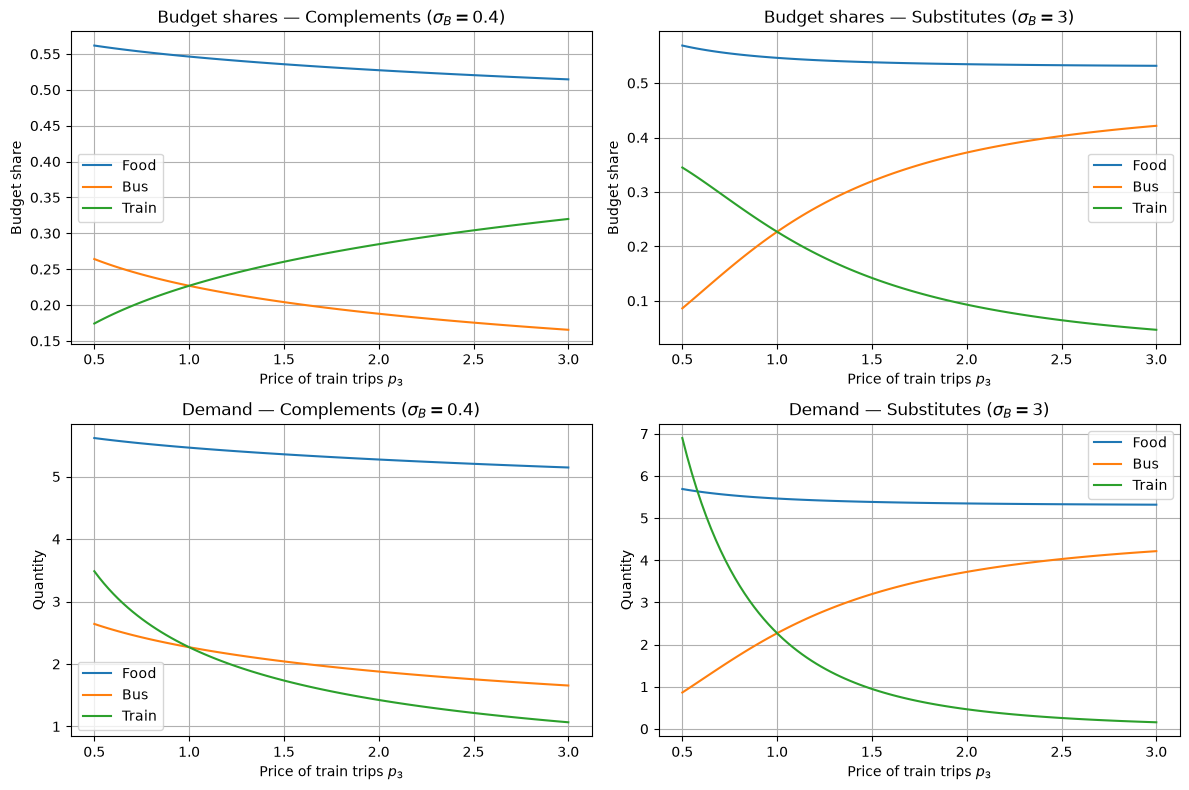

In [26]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# Budget shares - Complements
ax[0,0].plot(p3_grid, s1_comp, label='Food')
ax[0,0].plot(p3_grid, s2_comp, label='Bus')
ax[0,0].plot(p3_grid, s3_comp, label='Train')

ax[0,0].set_title('Budget shares — Complements ($\\sigma_B=0.4$)')
ax[0,0].set_xlabel('Price of train trips $p_3$')
ax[0,0].set_ylabel('Budget share')
ax[0,0].legend()
ax[0,0].grid(True)


# Budget shares - Substitutes
ax[0,1].plot(p3_grid, s1_sub, label='Food')
ax[0,1].plot(p3_grid, s2_sub, label='Bus')
ax[0,1].plot(p3_grid, s3_sub, label='Train')

ax[0,1].set_title('Budget shares — Substitutes ($\\sigma_B=3$)')
ax[0,1].set_xlabel('Price of train trips $p_3$')
ax[0,1].set_ylabel('Budget share')
ax[0,1].legend()
ax[0,1].grid(True)


# Quantities - Complements
ax[1,0].plot(p3_grid, x1_comp, label='Food')
ax[1,0].plot(p3_grid, x2_comp, label='Bus')
ax[1,0].plot(p3_grid, x3_comp, label='Train')

ax[1,0].set_title('Demand — Complements ($\\sigma_B=0.4$)')
ax[1,0].set_xlabel('Price of train trips $p_3$')
ax[1,0].set_ylabel('Quantity')
ax[1,0].legend()
ax[1,0].grid(True)


# Quantities - Substitutes
ax[1,1].plot(p3_grid, x1_sub, label='Food')
ax[1,1].plot(p3_grid, x2_sub, label='Bus')
ax[1,1].plot(p3_grid, x3_sub, label='Train')

ax[1,1].set_title('Demand — Substitutes ($\\sigma_B=3$)')
ax[1,1].set_xlabel('Price of train trips $p_3$')
ax[1,1].set_ylabel('Quantity')
ax[1,1].legend()
ax[1,1].grid(True)

plt.tight_layout()
plt.show()

The figures show that the response to a higher train price differs substantially between the two calibrations. The following questions examine these differences in more detail.

### 3.2 Train budget share

For complements, $\sigma_B = 0.4 < 1$. From the figure, the train budget share increases as `p3` increases. Even though the consumer buys fewer train trips, the higher price means that a larger share of the budget is spent on train trips.

For substitutes, $\sigma_B = 3 > 1$. Here, the train budget share decreases as `p3` increases. Since bus and train are substitutes, the consumer shifts expenditure away from the more expensive train and towards bus trips.

Therefore:
- Complements: higher `p3` increases the train budget share.
- Substitutes: higher `p3` decreases the train budget share.

### 3.3 Bus trips

For complements, $\sigma_B = 0.4$. When train tickets become more expensive, the consumer buys fewer train trips. Since bus and train are complements, the demand for bus trips also falls.

Therefore:

$p_3 \uparrow \Rightarrow x_3 \downarrow \Rightarrow x_2 \downarrow$

For substitutes, $\sigma_B = 3$. When train tickets become more expensive, the consumer substitutes away from train trips and towards bus trips.

Therefore:

$p_3 \uparrow \Rightarrow x_3 \downarrow \Rightarrow x_2 \uparrow$

The main difference is therefore that bus demand falls under complements, but increases under substitutes.

### 3.4 Demand for food

To compare the effect on food and bus demand, we calculate the percentage change in quantities between `p3 = 0.5` and `p3 = 3.0`.

In [27]:
food_change_comp = (
    (x1_comp[-1] - x1_comp[0])
    / x1_comp[0] * 100
)

bus_change_comp = (
    (x2_comp[-1] - x2_comp[0])
    / x2_comp[0] * 100
)

food_change_sub = (
    (x1_sub[-1] - x1_sub[0])
    / x1_sub[0] * 100
)

bus_change_sub = (
    (x2_sub[-1] - x2_sub[0])
    / x2_sub[0] * 100
)

print("Complements:")
print("Food:", food_change_comp, "%")
print("Bus:", bus_change_comp, "%")

print("\nSubstitutes:")
print("Food:", food_change_sub, "%")
print("Bus:", bus_change_sub, "%")

Complements:
Food: -8.393018675220478 %
Bus: -37.32920283756819 %

Substitutes:
Food: -6.539495185881841 %
Bus: 388.8347534879367 %


Food demand changes much less than bus demand when the price of train trips increases.

For complements, food demand falls by about 8.4%, while bus demand falls by about 37.3%.

For substitutes, food demand falls by about 6.5%, while bus demand increases by about 388.8%.

The effect on bus demand is therefore much stronger than the effect on food demand. This is because bus and train are in the same travel nest, while food is outside the lower bus/train nest. A change in the train price therefore affects bus demand more directly, while food is affected indirectly through the allocation between food and travel.